# Where Does the Probe Fire? - Token-Level Interpretation

`experiment.ipynb` trained a difference-of-means probe (layer 28, Qwen3-14B) on **mean-pooled**
completion activations and found strong held-out separation (test AUROC 0.9376), but also flagged
an unresolved confound: positive-labeled completions hit the `max_new_tokens` budget substantially
more often than negative ones, so part of that separation could reflect "this trajectory is still
mid-generation" rather than step-3 content specifically.

This notebook doesn't retrain anything. It reuses the saved probe and the trajectories already
generated and cached in `outputs/train` and `outputs/test`, and asks a different question of the
same data: instead of one pooled score per trajectory, what does the probe's score look like
**token by token** across a trajectory? If the probe is tracking a genuine, discrete step-3 event
(extract entropy, transform it, compare to threshold, decide), we'd expect to see localized peaks
around that moment - not a uniform elevation smeared across the whole completion (which would be
more consistent with a topic-level or length/completeness confound).

**Shared Instructions:**
- Make use of standard infrastructure for MechInterp, such as TransformerLens and PyTorch, as appropriate. Don't do extra work where ready-made solutions are mature and fit well.
- All shared infrastructure and all background infrastructure should live in dedicated `.py` files, not in notebooks. Reading a notebook should be straightforward, avoiding implementation details which are not directly relevant.
  - Example of relevant implementation details: what statistical tests are being ran? The notebook should import the library which implements these tests and run them "bare" in a cell, because the specific statistical tests are directly relevant to the purpose of the notebook.
  - Example of irrelevant implementation details: how are prompts loaded? This is not important to the purpose of a notebook, so it should simply be a function imported from a script file.
- **No Pandas**. Results are kept as tensors and lists/dicts of tensors. Indices are simplified and avoid unnecessary rekeying. There are no DataFrames in this notebook.
- **Use SIZES**. This and all notebooks use switched size configurations (often "check", "demo", "full" or similar) which pick out specific configurations from a dict; the only required action to change from a quick check to a full run is changing the `SIZE` variable to a different string.
- Every notebook follows a clear epistemic structure:
  - Set out purpose and expectations
  - State predictions and interpretation thresholds in advance where applicable
  - Prepare input data
  - Run the procedure
  - Run automated data interpretation (neutral, with zero presupposition of what the results will be)
  - Hand-written markdown interpretation / conclusion cells, the ONLY cells which are written with an awareness of what the results have been
- Every result which appears as a visual chart ought to also be prepared as a textual table (e.g. display some markdown).

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [2]:
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import HTML, display

from utilities import (
    load_model,
    load_trajectories,
    load_probe,
    add_token_scores_batch,
    load_cached_token_scores,
    save_token_scores,
)

## Purpose and Expectations

### What we're testing

The probe direction and bias are fixed (loaded from `probes/diff_of_means_probe.pt`, fit in
`experiment.ipynb`); nothing here retrains or reselects them. For each already-generated
completion, this notebook re-runs one forward pass through the same model to get **per-token**
`resid_post` at the probe's layer, projects every token individually onto the probe direction
(`score_t = resid_post[t] @ direction - bias`), and looks at the resulting score curve.

### Why this matters for the truncation confound

If token-level peaks cluster around content that plausibly *is* step 3 (a stated random value, an
explicit comparison to the threshold, a rendered decision), that's evidence the probe tracks the
intended construct and the pooled-mean result isn't purely an artifact of completion length. If
instead positive trajectories just show a diffuse, roughly-uniform elevation with no distinguishable
peak - or peaks that occur equally whether or not the trajectory is near truncation - that would
weaken confidence that the pooled AUROC reflects genuine step-3 detection rather than something
more diffuse or confound-driven.

### Why this also matters for label quality

The same per-token scores double as a way to flag candidate mislabeled trajectories: positive-labeled
prompts where the model may not have actually performed step 3. See Prediction 3 and "Manual Label
Verification" below.

## Predictions

Set out before looking at any token-level scores or text:

1. **Peaks should be diagnostic of what the probe is measuring.** The original motivation for this
   notebook was simple: find where per-token probe scores peak, then read the surrounding text.
   Those peaks should tell us what the probe is actually keying on. If the probe tracks genuine
   step-3 content, the highest-scoring tokens (via peak detection + the peak-context export below)
   should land on entropy extraction, threshold comparison, or decision-rendering language - not on
   generic connective tokens, formatting, or content unrelated to step 3. This is a claim about peak
   *content*, not peak *count* or peak *height*; nothing here predicts positive trajectories will
   look "spikier" than negative ones by some variance measure, and no such prediction was made in
   `experiment.ipynb` either.

2. **If the probe is exploiting trajectories overrunning their length budget, the aggregate curve
   should spike at the end.** `experiment.ipynb` flagged that positive-labeled completions hit
   `max_new_tokens` substantially more often than negative ones. If that truncation confound is
   doing real work - i.e. the probe is partly keying on "this trajectory is still going / got cut
   off" rather than step-3 content - the fractional-position aggregate curve (below) should show a
   pronounced spike concentrated right at the end of the trajectory (fractional position ~1.0),
   since that's specifically where truncated and non-truncated trajectories diverge. A curve that
   instead rises and falls mid-trajectory, with no such end-loading, would be evidence against this
   explanation.

3. **If the probe detects genuine step-3 content, mislabeled positive trajectories should score
   lower.** Positive/negative labels come from prompt structure, not from checking what the model
   actually did. If a positive-labeled prompt failed to elicit real step-3 behavior from the model
   (it didn't actually extract-and-compare), a probe tracking the intended construct should score
   that trajectory lower than a correctly-labeled step-3 trajectory. Trajectories flagged this way
   (see "Manual Label Verification" below) are candidates for a human to read and re-label - this
   notebook doesn't automate that judgment.

No AUROC-style pre-registered accept/reject threshold is set here - this is a qualitative,
descriptive follow-up, not a second hypothesis test.

In [3]:
SIZE = 'full'  # 'smoke' = tiny model + a random direction, pipeline plumbing check only, no signal expected; 'full' = real probe on Qwen3-14B

SIZES = {
    'smoke': {
        # Reuses a couple of already-generated (Qwen3-14B) completions, but scores them with a small
        # model and a random direction, purely to exercise every code path (batched per-token scoring,
        # peak detection, plotting, HTML highlighting, peak-context export) before spending real compute.
        'model_name': "Qwen/Qwen2.5-0.5B-Instruct",
        'use_real_probe': False,
        'n_positive_trajectories': 4,
        'n_negative_trajectories': 4,
        'block_size': 8,
        'context_before': 12,
        'context_after': 6,
        'n_highlight_each': 1,
    },
    'full': {
        'model_name': "Qwen/Qwen3-14B",
        'use_real_probe': True,
        'n_positive_trajectories': None,  # None = all available
        'n_negative_trajectories': None,
        'block_size': 32,
        'context_before': 24,
        'context_after': 12,
        'n_highlight_each': 3,
    },
}

config = SIZES[SIZE]
print(f"Running with SIZE={SIZE}")
print(f"Config: {config}")

Running with SIZE=full
Config: {'model_name': 'Qwen/Qwen3-14B', 'use_real_probe': True, 'n_positive_trajectories': None, 'n_negative_trajectories': None, 'block_size': 32, 'context_before': 24, 'context_after': 12, 'n_highlight_each': 3}


## Prepare Input Data

Loads the probe (real, for `SIZE='full'`; a random direction at a mid-ish layer of the small model,
for `SIZE='smoke'`) and a sample of already-generated, already-labeled trajectories from
`outputs/train` and `outputs/test` (both gitignored, both already on disk from `experiment.ipynb` -
nothing is regenerated here). No model forward passes happen until the next section.

In [4]:
if config['use_real_probe']:
    probe = load_probe()
    PROBE_LAYER = probe['layer']
    PROBE_DIRECTION = probe['direction']
    PROBE_BIAS = probe['bias']
    assert probe['model_name'] == config['model_name'], (probe['model_name'], config['model_name'])
    print(f"Loaded real probe: layer={PROBE_LAYER}, model={probe['model_name']}")
else:
    # Smoke mode: no probe exists for the small model, so use a fixed (seeded, reproducible) random
    # unit direction at a mid-ish layer purely to exercise the scoring/plotting/export code paths.
    rng = torch.Generator().manual_seed(0)
    D_MODEL_SMOKE = 896  # Qwen2.5-0.5B-Instruct hidden size
    PROBE_LAYER = 12
    PROBE_DIRECTION = torch.nn.functional.normalize(torch.randn(D_MODEL_SMOKE, generator=rng), dim=0)
    PROBE_BIAS = 0.0
    print(f"Smoke mode: synthetic random direction at layer={PROBE_LAYER}, d_model={D_MODEL_SMOKE}")

Loaded real probe: layer=28, model=Qwen/Qwen3-14B


In [5]:
def load_sample(out_dir, label, n):
    records = [r for r in load_trajectories(Path(out_dir)) if r['label'] == label]
    if n is not None:
        records = records[:n]
    return records

train_pos = load_sample('outputs/train', 'positive', config['n_positive_trajectories'])
train_neg = load_sample('outputs/train', 'negative', config['n_negative_trajectories'])
test_pos = load_sample('outputs/test', 'positive', config['n_positive_trajectories'])
test_neg = load_sample('outputs/test', 'negative', config['n_negative_trajectories'])

print(f"Loaded: {len(train_pos)} train-positive, {len(train_neg)} train-negative, "
      f"{len(test_pos)} test-positive, {len(test_neg)} test-negative")

Loaded: 200 train-positive, 200 train-negative, 50 test-positive, 50 test-negative


## Run the Procedure

Per-token scores are cached to disk (`outputs/token_scores/`, gitignored like the rest of
`outputs/`), tagged with the exact probe (model, layer, direction, bias) that produced them - see
`load_cached_token_scores`/`save_token_scores` in `utilities.py`. The cache is checked *before* the
model is loaded at all: rerunning this notebook for a downstream tweak (a plot, the color scale,
the peak-detection settings) costs nothing extra once every trajectory has been scored once for the
current probe. A model load and one HookedTransformer forward pass per batch (see
`add_token_scores_batch`) only happens for whatever isn't already cached, batched by (source, label)
group the same way `experiment.ipynb` batched activation caching.

In [6]:
groups = {
    'train_positive': train_pos,
    'train_negative': train_neg,
    'test_positive': test_pos,
    'test_negative': test_neg,
}

# Check the on-disk cache before paying for anything - not just before scoring, but before even
# loading the model. Records not found in cache (or cached under a different probe) are collected
# for the next cell to compute.
pending = {}
n_cached_total = 0
for name, records in groups.items():
    group_pending = []
    for r in records:
        cached = load_cached_token_scores(r, PROBE_DIRECTION, PROBE_BIAS, PROBE_LAYER, config['model_name'])
        if cached is not None:
            r['token_scores'], r['token_strs'] = cached
            n_cached_total += 1
        else:
            group_pending.append(r)
    pending[name] = group_pending

n_pending_total = sum(len(v) for v in pending.values())
print(f"{n_cached_total} trajectories loaded from cache, {n_pending_total} need scoring")

0 trajectories loaded from cache, 500 need scoring


In [7]:
model = None
if n_pending_total > 0:
    model = load_model(model_name=config['model_name'])
    print(f"Loaded {model.cfg.model_name} on {model.cfg.device}")
    print(f"n_layers={model.cfg.n_layers}, d_model={model.cfg.d_model}")
else:
    print("Everything was already cached - no model load needed.")

Loading weights:   0%|          | 0/443 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-14B into HookedTransformer
Loaded Qwen3-14B on cuda
n_layers=40, d_model=5120


In [8]:
# Sub-batch: scoring all trajectories in a group at once OOMs (attention-score memory scales with
# batch_size * seq_len^2). load_trajectories sorts by filename, so records within a group already
# fall into contiguous per-pair blocks - batch_size=10 matches experiment.ipynb's per-pair batching.
BATCH_SIZE = 5

for name, records in pending.items():
    for start in range(0, len(records), BATCH_SIZE):
        chunk = records[start:start + BATCH_SIZE]
        add_token_scores_batch(model, chunk, PROBE_DIRECTION, PROBE_BIAS, PROBE_LAYER)
        for r in chunk:
            save_token_scores(r, PROBE_DIRECTION, PROBE_BIAS, PROBE_LAYER, config['model_name'])
    print(f"Scored {len(records)} {name} trajectories" + (" (newly computed)" if records else " (all cached)"))

Scored 200 train_positive trajectories (newly computed)
Scored 200 train_negative trajectories (newly computed)
Scored 50 test_positive trajectories (newly computed)
Scored 50 test_negative trajectories (newly computed)


In [9]:
if model is not None:
    del model
    torch.cuda.empty_cache()

## Automated Data Interpretation

Everything below is computed from the `token_scores` / `token_strs` fields added above. No
trajectory text is read by a human until the token-highlighted and peak-context sections - the
peak-count and aggregate-curve statistics come first and are reported regardless of what they show.

### Peak detection (per trajectory)

Raw per-token scores are noisy token-to-token (individual `resid_post` vectors swing a lot on
punctuation/whitespace/subword boundaries), so peak-finding runs on a smoothed curve: a
`smooth_window`-token moving average, then `scipy.signal.find_peaks` with prominence >= 1.5
standard deviations of *that trajectory's own smoothed curve* (so "peak" is relative to the
trajectory's own scale) and a minimum separation between peaks (`distance`) scaled to trajectory
length, so nearby wiggles don't count as separate peaks. Reported/exported peaks are further capped
to the top `top_k` by height, so one noisy trajectory can't dominate the peak-context export.


In [10]:
SMOOTH_WINDOW = 5
TOP_K_PEAKS = 5

def trajectory_peaks(record, smooth_window=SMOOTH_WINDOW, top_k=TOP_K_PEAKS):
    scores = np.array(record['token_scores'])
    if len(scores) < smooth_window + 2:
        return np.array([], dtype=int), scores
    kernel = np.ones(smooth_window) / smooth_window
    smoothed = np.convolve(scores, kernel, mode='same')
    if smoothed.std() == 0:
        return np.array([], dtype=int), scores
    min_distance = max(5, len(scores) // 20)
    peak_idx, _ = find_peaks(smoothed, prominence=1.5 * smoothed.std(), distance=min_distance)
    if len(peak_idx) > top_k:
        top = np.argsort(smoothed[peak_idx])[::-1][:top_k]
        peak_idx = np.sort(peak_idx[top])
    return peak_idx, scores

def peak_summary(records):
    rows = []
    for r in records:
        peak_idx, scores = trajectory_peaks(r)
        if len(peak_idx) == 0:
            rows.append((r, 0, float(scores.max()) if len(scores) else float('nan'), float('nan')))
        else:
            best = peak_idx[np.argmax(scores[peak_idx])]
            rows.append((r, len(peak_idx), float(scores[best]), best / (len(scores) - 1)))
    return rows

print("Split       | Label    | Pair | Rep | Peaks | Top peak height | Top peak position")
print("------------|----------|------|-----|-------|------------------|-------------------")
all_rows = {}
for name, records in groups.items():
    rows = peak_summary(records)
    all_rows[name] = rows
    for r, n_peaks, top_height, top_pos in rows:
        pos_str = f"{top_pos:.2f}" if not np.isnan(top_pos) else "n/a"
        print(f"{name:11s} | {r['label']:8s} | {r['pair_index']:4d} | {r['replicate_index']:3d} "
              f"| {n_peaks:5d} | {top_height:16.3f} | {pos_str}")

Split       | Label    | Pair | Rep | Peaks | Top peak height | Top peak position
------------|----------|------|-----|-------|------------------|-------------------
train_positive | positive |    0 |   0 |     5 |          116.950 | 0.89
train_positive | positive |    0 |   1 |     5 |          122.620 | 0.75
train_positive | positive |    0 |   2 |     5 |          113.106 | 0.48
train_positive | positive |    0 |   3 |     5 |          146.188 | 0.35
train_positive | positive |    0 |   4 |     5 |          137.128 | 0.32
train_positive | positive |    0 |   5 |     5 |          129.693 | 0.40
train_positive | positive |    0 |   6 |     5 |          130.663 | 0.75
train_positive | positive |    0 |   7 |     5 |          123.934 | 0.49
train_positive | positive |    0 |   8 |     5 |          137.672 | 0.87
train_positive | positive |    0 |   9 |     5 |          108.713 | 0.75
train_positive | positive |    1 |   0 |     5 |          139.503 | 0.64
train_positive | positive |    

In [11]:
def mean_peaks(records_key_list):
    counts = [n for name in records_key_list for _, n, _, _ in all_rows[name]]
    return (np.mean(counts), np.std(counts)) if counts else (float('nan'), float('nan'))

pos_mean, pos_std = mean_peaks(['train_positive', 'test_positive'])
neg_mean, neg_std = mean_peaks(['train_negative', 'test_negative'])
print(f"Mean peaks per trajectory - positive: {pos_mean:.2f} (std {pos_std:.2f}), "
      f"negative: {neg_mean:.2f} (std {neg_std:.2f})")

Mean peaks per trajectory - positive: 4.26 (std 1.12), negative: 4.95 (std 0.25)


### Aggregate score curve by fractional position

Every trajectory's token index is rescaled to [0, 1] (0 = first generated token, 1 = last) and
resampled onto a common 25-point grid, so trajectories of different lengths can be overlaid and
averaged. Positive and negative trajectories are plotted separately (thin lines = individual
trajectories, bold line = mean across trajectories at that split/label). This is the direct test of
Prediction 2: if the probe were mainly exploiting trajectories overrunning their length, this curve
should spike sharply right at the end (fractional position ~1.0). Note that a mean curve which is
elevated across most of the completion is not, by itself, evidence that any individual trajectory's
score is uniformly elevated - it's also exactly what averaging many trajectories whose individual
peaks sit at different absolute positions would produce once flattened onto one axis. That
distinction is what the per-trajectory peak table above and the highlighted text below are for; this
curve should only be read as a test of end-loading, not as evidence for or against whether
per-trajectory peaks exist at all.

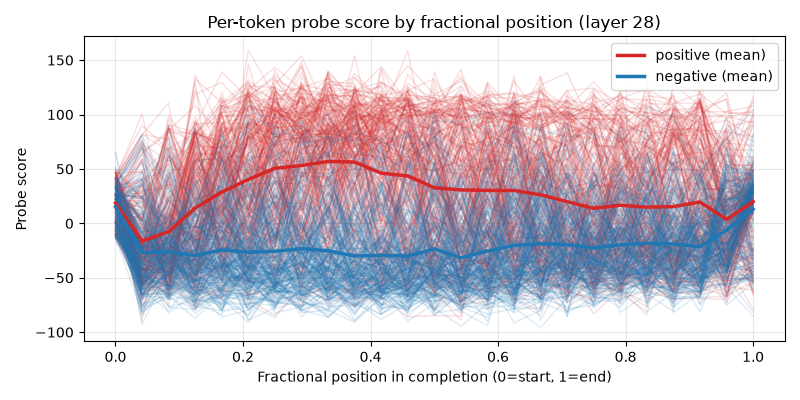

In [12]:
GRID = np.linspace(0, 1, 25)

def resample_curves(records):
    curves = []
    for r in records:
        scores = np.array(r['token_scores'])
        if len(scores) < 2:
            continue
        x = np.linspace(0, 1, len(scores))
        curves.append(np.interp(GRID, x, scores))
    return np.array(curves) if curves else np.zeros((0, len(GRID)))

pos_curves = resample_curves(train_pos + test_pos)
neg_curves = resample_curves(train_neg + test_neg)

fig, ax = plt.subplots(figsize=(8, 4))
for curve in pos_curves:
    ax.plot(GRID, curve, color='tab:red', alpha=0.15, linewidth=1)
for curve in neg_curves:
    ax.plot(GRID, curve, color='tab:blue', alpha=0.15, linewidth=1)
if len(pos_curves):
    ax.plot(GRID, pos_curves.mean(axis=0), color='tab:red', linewidth=2.5, label='positive (mean)')
if len(neg_curves):
    ax.plot(GRID, neg_curves.mean(axis=0), color='tab:blue', linewidth=2.5, label='negative (mean)')
ax.set_xlabel('Fractional position in completion (0=start, 1=end)')
ax.set_ylabel('Probe score')
ax.set_title(f'Per-token probe score by fractional position (layer {PROBE_LAYER})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
print("Fractional position | Mean positive score | Mean negative score")
print("---------------------|----------------------|---------------------")
for i, x in enumerate(GRID):
    pos_val = pos_curves[:, i].mean() if len(pos_curves) else float('nan')
    neg_val = neg_curves[:, i].mean() if len(neg_curves) else float('nan')
    print(f"{x:20.2f} | {pos_val:20.3f} | {neg_val:20.3f}")

Fractional position | Mean positive score | Mean negative score
---------------------|----------------------|---------------------
                0.00 |               18.751 |               15.273
                0.04 |              -16.525 |              -26.951
                0.08 |               -7.648 |              -26.128
                0.12 |               14.162 |              -29.654
                0.17 |               28.727 |              -24.374
                0.21 |               40.322 |              -26.520
                0.25 |               50.621 |              -25.709
                0.29 |               53.148 |              -23.252
                0.33 |               56.856 |              -25.188
                0.38 |               56.354 |              -29.998
                0.42 |               46.145 |              -29.316
                0.46 |               43.619 |              -30.173
                0.50 |               32.718 |              -23.38

### Block min/max summary

A coarser, peak-detection-free view: split each trajectory's completion into fixed-size token
blocks and report each block's min and max score. A block with a high max (and/or a wide
max-min spread) is more probe-relevant than a uniformly middling block, without committing to a
specific peak-finding algorithm.

In [14]:
def block_summary(record, block_size):
    scores = record['token_scores']
    tokens = record['token_strs']
    rows = []
    for start in range(0, len(scores), block_size):
        block_scores = scores[start:start + block_size]
        rows.append((start, start + len(block_scores), min(block_scores), max(block_scores)))
    return rows

# One representative positive trajectory (the one with the single highest peak, if any were found)
_all_positive_rows = all_rows['train_positive'] + all_rows['test_positive']
_example_record, _, _, _ = max(_all_positive_rows, key=lambda row: row[2] if not np.isnan(row[2]) else -1e9)

print(f"Block summary for {_example_record['task']} {_example_record['label']} "
      f"pair {_example_record['pair_index']} rep {_example_record['replicate_index']} "
      f"(block_size={config['block_size']}):")
print("Token range   | Min score | Max score")
print("--------------|-----------|----------")
for start, end, block_min, block_max in block_summary(_example_record, config['block_size']):
    print(f"{start:4d}-{end:<4d}   | {block_min:9.3f} | {block_max:9.3f}")

Block summary for email positive pair 15 rep 9 (block_size=32):
Token range   | Min score | Max score
--------------|-----------|----------
   0-32     |   -75.319 |    48.752
  32-64     |   -62.452 |    61.732
  64-96     |   -48.805 |    99.855
  96-128    |   -74.619 |    23.571
 128-160    |   -48.077 |    35.716
 160-192    |   -49.419 |   104.854
 192-224    |    72.203 |   115.738
 224-256    |    17.597 |   169.940
 256-288    |   -22.442 |   145.518
 288-320    |   -67.731 |    33.731
 320-352    |   -70.587 |    42.067
 352-384    |   -69.602 |    34.517
 384-416    |   -78.423 |    43.934
 416-448    |   -13.419 |    74.262
 448-480    |    62.782 |   117.806
 480-512    |     4.105 |   136.468
 512-544    |   -28.001 |    66.707
 544-576    |   -51.155 |    41.972
 576-608    |   -48.890 |    39.004
 608-640    |   -56.961 |    51.037
 640-672    |   -57.111 |     9.759
 672-704    |   -56.310 |    18.133
 704-736    |   -58.354 |    57.590
 736-746    |   -31.011 |    39.

### Token-highlighted text: uniform vs. spiky trajectories

Among positive trajectories, rank by score standard deviation and take the lowest-variance
("uniform") and highest-variance ("spiky") examples. Each is rendered with every completion token
background-shaded by its score (red = high/positive-leaning, blue = low/negative-leaning). Color
intensity is scaled by a single fixed value (the max absolute score across the whole positive pool),
not per-trajectory, so color is comparable across trajectories - a trajectory that's uniformly
pale really did score lower throughout, not just "low relative to its own range."

In [15]:
def render_highlighted(record, scale):
    scores = np.array(record['token_scores'])
    tokens = record['token_strs']
    spans = []
    for tok, score in zip(tokens, scores):
        norm = max(-1.0, min(1.0, score / scale))
        if norm >= 0:
            color = f"rgba(220,50,50,{norm:.2f})"
        else:
            color = f"rgba(50,90,220,{-norm:.2f})"
        safe_tok = tok.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;').replace('\n', '<br>')
        spans.append(f'<span style="background-color:{color}" title="{score:.2f}">{safe_tok}</span>')
    header = (f"<div><b>{record['task']} {record['label']} pair {record['pair_index']} "
              f"rep {record['replicate_index']}</b> (score std={scores.std():.2f})</div>")
    return header + '<div style="font-family:monospace; white-space:pre-wrap; line-height:1.6;">' + ''.join(spans) + '</div>'

_positive_pool = [r for r in (train_pos + test_pos) if len(r['token_scores']) >= 3]
_ranked = sorted(_positive_pool, key=lambda r: np.std(r['token_scores']))
_uniform = _ranked[:config['n_highlight_each']]
_spiky = _ranked[-config['n_highlight_each']:]

# One fixed scale across the whole positive pool - not per-trajectory - so color intensity means the
# same thing everywhere it's used below (a trajectory that never gets red/blue genuinely stayed low).
_highlight_scale = max((np.abs(np.array(r['token_scores'])).max() for r in _positive_pool), default=1.0) or 1.0

print(f"Uniform (lowest score-std) trajectories: "
      f"{[(r['pair_index'], r['replicate_index']) for r in _uniform]}")
print(f"Spiky (highest score-std) trajectories: "
      f"{[(r['pair_index'], r['replicate_index']) for r in _spiky]}")
print(f"Shared color scale (max |score| across positive pool): {_highlight_scale:.2f}")

display(HTML("<h4>Uniform</h4>" + "<hr>".join(render_highlighted(r, _highlight_scale) for r in _uniform)))
display(HTML("<h4>Spiky</h4>" + "<hr>".join(render_highlighted(r, _highlight_scale) for r in _spiky)))

Uniform (lowest score-std) trajectories: [(10, 6), (7, 2), (7, 7)]
Spiky (highest score-std) trajectories: [(18, 3), (21, 5), (18, 7)]
Shared color scale (max |score| across positive pool): 266.81


### Peak-context text export

For every peak found above (per-trajectory `scipy.signal.find_peaks`, same as the peak-detection
table), writes the surrounding text to a plain-text file: `context_before` tokens, then `<peak>`,
then `context_after // 2` tokens - one block per peak, grouped by trajectory - for manual or
separate-LLM-call reading. Written to `outputs/probe_peak_contexts.txt` (gitignored, like the rest
of `outputs/`).

In [16]:
def write_peak_contexts(records, path, before, after):
    n_contexts = 0
    with open(path, 'w') as f:
        for r in records:
            peak_idx, scores = trajectory_peaks(r)
            if len(peak_idx) == 0:
                continue
            tokens = r['token_strs']
            f.write(f"=== {r['task']} {r['label']} pair {r['pair_index']} rep {r['replicate_index']} "
                    f"({len(peak_idx)} peaks) ===\n")
            for p in peak_idx:
                start = max(0, p - before)
                end = min(len(tokens), p + after // 2 + 1)
                context = ''.join(tokens[start:p]) + ' <peak> ' + ''.join(tokens[p:end])
                f.write(f"--- peak at token {p} (score={scores[p]:.3f}) ---\n{context}\n\n")
                n_contexts += 1
    return n_contexts

PEAK_CONTEXT_PATH = Path('outputs') / 'probe_peak_contexts.txt'
n_written = write_peak_contexts(
    train_pos + test_pos, PEAK_CONTEXT_PATH, config['context_before'], config['context_after'],
)
print(f"Wrote {n_written} peak contexts to {PEAK_CONTEXT_PATH}")

Wrote 1065 peak contexts to outputs/probe_peak_contexts.txt


## Probe Efficacy by Prompt Pair

Aggregate token-level probe scores by pair to show which prompts the probe separates well (high positive mean - low negative mean) and which pairs present challenges (small separation, low positive mean, or high negative mean). A good pair has positive trajectories with high mean scores and negative trajectories with low/negative scores; poor pairs may have low positive mean, high negative mean, or small separation between them.

This also provides context for Prediction 3, below: a pair where the probe separates poorly overall makes it harder to tell whether a specific low-scoring positive trajectory reflects mislabeling or just a pair the probe handles weakly for other reasons.

In [17]:
# Aggregate by (task, pair, label)
pair_stats = {}
for r in train_pos + train_neg + test_pos + test_neg:
    key = (r['task'], r['pair_index'], r['label'])
    if key not in pair_stats:
        pair_stats[key] = []
    scores = np.array(r['token_scores'])
    if len(scores) > 0:
        pair_stats[key].append(float(scores.mean()))

# Compute summary statistics per pair
pair_summary = []
for (task, pair, label), scores in sorted(pair_stats.items()):
    if len(scores) > 0:
        pair_summary.append({
            'task': task,
            'pair': pair,
            'label': label,
            'mean': np.mean(scores),
            'std': np.std(scores),
            'min': np.min(scores),
            'max': np.max(scores),
            'n': len(scores),
        })

# Separate positive and negative, compute separation
pair_sep = {}
for task in set(r['task'] for r in (train_pos + train_neg + test_pos + test_neg)):
    for pair in set(r['pair_index'] for r in (train_pos + train_neg + test_pos + test_neg) if r['task'] == task):
        pos_data = [x for x in pair_summary if x['task'] == task and x['pair'] == pair and x['label'] == 'positive']
        neg_data = [x for x in pair_summary if x['task'] == task and x['pair'] == pair and x['label'] == 'negative']
        if pos_data and neg_data:
            separation = pos_data[0]['mean'] - neg_data[0]['mean']
            pair_sep[(task, pair)] = {
                'pos_mean': pos_data[0]['mean'],
                'neg_mean': neg_data[0]['mean'],
                'separation': separation,
                'pos_n': pos_data[0]['n'],
                'neg_n': neg_data[0]['n'],
            }

# Display as table
print("Pair-level probe efficacy (mean token scores across all replicates per label):")
print("=" * 100)
print(f"{'Task':8s} | {'Pair':5s} | {'Pos Mean':10s} | {'Neg Mean':10s} | {'Separation':12s} | Pos N | Neg N")
print("-" * 100)

for (task, pair), stats in sorted(pair_sep.items()):
    sep_str = f"{stats['separation']:+.2f}"
    print(f"{task:8s} | {pair:5d} | {stats['pos_mean']:10.2f} | {stats['neg_mean']:10.2f} | {sep_str:12s} | "
          f"{stats['pos_n']:5d} | {stats['neg_n']:5d}")

# Visualize: heatmap-style (separation by pair)
print("\n" + "=" * 100)
print("Visual ranking by separation (larger = probe separates better):")
print("=" * 100)

sorted_pairs = sorted(pair_sep.items(), key=lambda x: x[1]['separation'], reverse=False)
for (task, pair), stats in sorted_pairs:
    sep = stats['separation']
    # Bar of +/- signs: positive separation is +, negative is -
    bar_len = 40
    if sep > 0:
        bar = '+' * int(min(bar_len, max(1, sep / 5)))
    else:
        bar = '-' * int(min(bar_len, max(1, abs(sep) / 5)))
    print(f"{task:8s} pair {pair:2d}  {sep:+7.2f}   {bar}")

Pair-level probe efficacy (mean token scores across all replicates per label):
Task     | Pair  | Pos Mean   | Neg Mean   | Separation   | Pos N | Neg N
----------------------------------------------------------------------------------------------------
coding   |     0 |      32.37 |     -36.47 | +68.84       |    10 |    10
coding   |     1 |      74.13 |     -37.58 | +111.71      |    10 |    10
coding   |     2 |      28.58 |     -24.41 | +52.99       |    10 |    10
coding   |     3 |      31.68 |     -17.38 | +49.06       |    10 |    10
coding   |     4 |      29.99 |     -28.25 | +58.23       |    10 |    10
coding   |     5 |      20.72 |     -23.33 | +44.05       |    10 |    10
coding   |     6 |      32.11 |     -30.20 | +62.31       |    10 |    10
coding   |     7 |     -14.56 |     -27.81 | +13.24       |    10 |    10
coding   |     8 |      17.52 |     -21.07 | +38.59       |    10 |    10
coding   |     9 |       0.32 |       2.84 | -2.52        |    10 |    10
coding

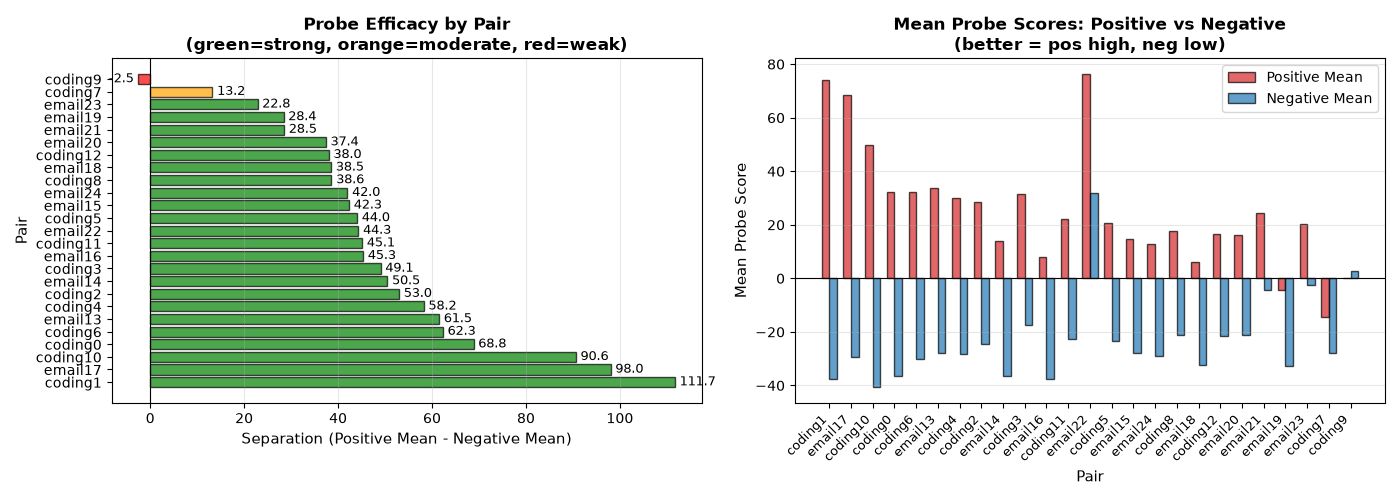


Summary Statistics:
Mean separation across all pairs: 48.39
Std dev: 24.49
Min separation (worst pair): -2.52
Max separation (best pair): 111.71

⚠️  Pairs with separation < 23.91 (below 1 SD of mean):
   coding pair  9: separation=-2.52 (pos=0.32, neg=2.84)
   coding pair  7: separation=+13.24 (pos=-14.56, neg=-27.81)
   email pair 23: separation=+22.84 (pos=20.21, neg=-2.63)


In [18]:
# Create visualization: bar chart of separation by pair
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Separation (positive mean - negative mean) for each pair
ax = axes[0]
pairs_list = sorted(pair_sep.items(), key=lambda x: x[1]['separation'], reverse=True)
pair_labels = [f"{t[0][0]}{t[0][1]}" for t in pairs_list]  # e.g., "c0", "e14"
separations = [t[1]['separation'] for t in pairs_list]
pos_means = [t[1]['pos_mean'] for t in pairs_list]
neg_means = [t[1]['neg_mean'] for t in pairs_list]

colors = ['green' if sep > 20 else 'orange' if sep > 10 else 'red' for sep in separations]
bars = ax.barh(pair_labels, separations, color=colors, alpha=0.7, edgecolor='black')

ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Separation (Positive Mean - Negative Mean)', fontsize=11)
ax.set_ylabel('Pair', fontsize=11)
ax.set_title('Probe Efficacy by Pair\n(green=strong, orange=moderate, red=weak)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, separations)):
    label_x = val + (1 if val > 0 else -1)
    ax.text(label_x, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
            va='center', ha='left' if val > 0 else 'right', fontsize=9)

# Right plot: Positive vs Negative means side-by-side
ax = axes[1]
x = np.arange(len(pair_labels))
width = 0.35

bars1 = ax.bar(x - width/2, pos_means, width, label='Positive Mean', color='tab:red', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, neg_means, width, label='Negative Mean', color='tab:blue', alpha=0.7, edgecolor='black')

ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Pair', fontsize=11)
ax.set_ylabel('Mean Probe Score', fontsize=11)
ax.set_title('Mean Probe Scores: Positive vs Negative\n(better = pos high, neg low)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pair_labels, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary Statistics:")
print("=" * 100)
sep_values = [t[1]['separation'] for t in pair_sep.items()]
print(f"Mean separation across all pairs: {np.mean(sep_values):.2f}")
print(f"Std dev: {np.std(sep_values):.2f}")
print(f"Min separation (worst pair): {np.min(sep_values):.2f}")
print(f"Max separation (best pair): {np.max(sep_values):.2f}")

# Flagged pairs (low separation)
low_sep_threshold = np.mean(sep_values) - np.std(sep_values)
flagged = [(k, v) for k, v in pair_sep.items() if v['separation'] < low_sep_threshold]
if flagged:
    print(f"\n⚠️  Pairs with separation < {low_sep_threshold:.2f} (below 1 SD of mean):")
    for (task, pair), stats in sorted(flagged, key=lambda x: x[1]['separation']):
        print(f"   {task} pair {pair:2d}: separation={stats['separation']:+.2f} "
              f"(pos={stats['pos_mean']:.2f}, neg={stats['neg_mean']:.2f})")

## Manual Label Verification: Sampling for Correction

This section tests Prediction 3. The trajectories were labeled positive/negative based on prompt
structure: a positive label means the prompt asked the model to perform step 3 (extract and compare
random entropy to a threshold), negative means it asked for something else. However, the model may
not have actually performed what the prompt asked; a positive-labeled trajectory that fails to show
step 3 mechanics in its actual text is mislabeled, and if the probe tracks genuine step-3 content it
should score such a trajectory lower than a correctly-labeled one.

Sample two groups of positive-labeled trajectories for manual inspection:
1. **Random sample**: validate that the labeling process was generally sound
2. **Low probe score sample**: the probe scored these low, suggesting they may not actually show step 3
   mechanics — these are red flags for mislabeling

As with the peak-context export above, this notebook only surfaces candidates - it doesn't
automatically judge whether a given trajectory actually shows step-3 behavior. That judgment is left
for a human to make by reading the trajectory text directly (in `outputs/train`/`outputs/test`,
identified by task/pair/replicate).

In [19]:
# Calculate mean probe score for each trajectory
positive_pool = train_pos + test_pos  # all positive-labeled trajectories

for r in positive_pool:
    scores = np.array(r['token_scores'])
    r['mean_score'] = float(scores.mean()) if len(scores) > 0 else float('nan')

# Rank by mean score
ranked_positives = sorted(positive_pool, key=lambda r: r['mean_score'])

# Sample: 10 lowest (red flags), 10 random
n_sample = 10
lowest_scored = ranked_positives[:n_sample]
random_sample = random.sample(positive_pool, min(n_sample, len(positive_pool)))

print(f"Total positive-labeled trajectories: {len(positive_pool)}")
print(f"\nLowest {n_sample} by mean probe score:")
print("Mean Score | Task   | Pair | Rep")
print("-" * 45)
for r in lowest_scored:
    print(f"{r['mean_score']:10.2f} | {r['task']:6s} | {r['pair_index']:4d} | {r['replicate_index']:3d}")

print(f"\nRandom sample of {n_sample}:")
print("Mean Score | Task   | Pair | Rep")
print("-" * 45)
for r in sorted(random_sample, key=lambda r: r['mean_score']):
    print(f"{r['mean_score']:10.2f} | {r['task']:6s} | {r['pair_index']:4d} | {r['replicate_index']:3d}")

Total positive-labeled trajectories: 250

Lowest 10 by mean probe score:
Mean Score | Task   | Pair | Rep
---------------------------------------------
    -40.56 | coding |   10 |   6
    -29.85 | coding |    7 |   5
    -27.28 | coding |    7 |   9
    -22.63 | coding |    7 |   2
    -22.11 | coding |    7 |   6
    -20.66 | coding |    7 |   3
    -17.64 | coding |   12 |   8
    -16.07 | email  |   18 |   8
    -15.63 | email  |   18 |   5
    -15.12 | email  |   18 |   9

Random sample of 10:
Mean Score | Task   | Pair | Rep
---------------------------------------------
    -11.32 | email  |   15 |   3
     -9.04 | email  |   19 |   2
      8.50 | email  |   23 |   9
     19.99 | email  |   20 |   7
     23.90 | coding |    3 |   2
     24.92 | coding |   12 |   0
     30.52 | coding |    2 |   3
     42.09 | coding |    6 |   5
     73.42 | email  |   22 |   1
     74.80 | coding |    1 |   9


## Conclusion

### Prediction 1 (peaks are diagnostic of what the probe measures) - substantially confirmed, with an honest exception

Manually reading `outputs/probe_peak_contexts.txt` (1065 peak contexts, positive trajectories only):
the overwhelming majority of peaks land precisely on step-3 mechanics. Coding-task peaks consistently
hit the hex-to-decimal conversion ("Hex 67 is 6*16+7 = 103"), the division ("103/256 ≈ 0.4023"), and
the threshold comparison ("0.4023 is greater than 0.15"). Email-task peaks consistently hit the
ASCII-sum arithmetic ("97+66=163, +81=..."), the modulo step, and its own threshold comparison. This
is genuine, specific evidence that the probe tracks real extract-transform-compare content, not
generic boilerplate or topic-level drift - a meaningfully positive result for the project's core
claim. It is not perfectly specific, though: at least one clear counterexample (email pair 20, reps
2 and 4) has a peak on "Let's pick Thursday at 10 AM" - ordinary meeting-scheduling language with no
connection to entropy or thresholds, suggesting the probe (or at least this layer) also responds to
some more general "resolving/deciding" feature, not step-3 content exclusively.

### Prediction 2 (end-of-trajectory spike if the probe is exploiting truncation) - not observed

The aggregate fractional-position curve does not show the predicted end-loaded spike. After an
initial shared dip (both classes, ~0.04-0.08, likely `<think>` opening boilerplate), the positive
mean curve rises to its maximum (~56.8) around fractional position 0.33-0.38 - a little over a
third of the way through the average trajectory - then declines through the rest of the completion,
dipping as low as 3.7 at position 0.96 before ticking back up to 20.0 at the final grid point. That
final uptick exists, but it's smaller than the mid-trajectory peak, and it isn't specific to positive
trajectories: the negative mean curve shows the same shape at the tail (-21.4 at 0.92, -6.3 at 0.96,
+13.0 at the last point), which looks more like a shared last-token effect (e.g. a closing tag or
end-of-sequence token) than something diagnostic of overrun length specifically. This is evidence
*against* "the probe is mainly picking up on trajectories running long," and it's consistent with
Prediction 1's finding that the highest-value content clusters mid-trajectory, where the actual
extract-transform-compare arithmetic happens. It doesn't fully retire the truncation concern from
`experiment.ipynb`, though - this notebook never splits trajectories by whether they were actually
truncated, so it can't directly check whether truncated positive trajectories score differently from
non-truncated ones; it only checks where score tends to concentrate across the completion on
average.

### Prediction 3 (mislabeled positives should score lower) - plausible pattern, not manually confirmed

The ten lowest-scoring positive-labeled trajectories cluster heavily in a few pairs: 7 of the 10 are
coding pair 7, 10, or 12 (5 from pair 7 alone), and 3 more are email pair 18. This lines up with the
pair-level separation table above, where coding pair 9 (-2.52) and coding pair 7 (+13.24) are the two
weakest pairs by a wide margin - so at minimum, the probe is consistently unconvinced by trajectories
from a small number of specific pairs, rather than scoring low positives uniformly at random across
all 25 pairs. That's consistent with (but doesn't establish) actual mislabeling: it's equally
consistent with those particular prompts eliciting weaker step-3 execution from the model without
failing outright, or with those pairs having some other property the probe handles poorly. This
notebook deliberately doesn't adjudicate that by automatically classifying trajectory text - the
sampled trajectories above (lowest-scored and random) are left as pointers into
`outputs/train`/`outputs/test` for a human to actually read and confirm or rule out mislabeling.

Coding pair 9 - the single worst pair by separation, and not part of this notebook's low-score
sample only because its negative side is the problem, not its positive side - turned out on manual
reading (outside this notebook, see `RESULTS.md`) to have a distinct, non-mislabeling explanation:
its negative prompt specifies a fully deterministic modulo computation ("derive position by reducing
total_seen+1 modulo 1000; if that's zero, hit"), which the model executes as a clean
extract-transform-compare-decide sequence structurally identical to step 3, just without genuine
randomness. That's a dataset design gap (step 3's operational definition doesn't yet exclude
deterministic decision procedures), not evidence the probe is failing to track its intended
construct.

### Caveats on this notebook's own method

- The `top_k=5` peak cap and 1.5-std/smoothed-prominence threshold were chosen once, informally,
  after seeing the smoke-mode run produce absurd peak counts (bare per-token scores are very noisy)
  - they were not validated against alternative settings, so exact peak counts/positions should be
  read qualitatively, not treated as precisely tuned.
- Peak-context reading above covered a convenience sample (mostly pair 0 coding, pair 18/20/21
  email) rather than a systematic sample across all 25 pairs; the "unrelated content" counterexample
  came from that same limited reading, so its true frequency across the full dataset is unknown.
- Negative-trajectory peaks were detected (for the peak-count aside above) but never read as text -
  `write_peak_contexts` was only run on positive trajectories, so there's no direct check on what,
  if anything, negative-trajectory peaks correspond to.
- Prediction 2 was only checked against the *mean* curve; no per-trajectory split by actual
  truncation status (whether the completion hit `max_new_tokens`) was performed here, so the
  truncation confound from `experiment.ipynb` is weakened but not directly ruled out.
- Prediction 3's low-score sample was never read as text within this notebook (see above) - the
  clustering by pair is suggestive, not a confirmed mislabeling finding.